# Ideal Gas law and Kinetic Theory of gases Simulation 
### Guilherme C. Schewtschik, Matrikelnummer: 3748052

## Introduction

In this project we will verify the Ideal gas law using the kinetic theory of gases and explore its validity in different intial conditions, the Ideal gas law $^{[1]}$ is as follows: 
\begin{equation*}
    PV = NKT
\end{equation*}
where $P$ is pressure, $V$ volume, $N$ number of particles, $K$ the Boltzmann constant and $T$ temperature.




The cornerstone of this simulation is the Kinetic Theory of gases, which relates macro and micro properties of a closed system, the Theory states that we can treat a gas as a collection of many small particles, and that properties like temperature and pressure are nothing more than macroscopic manifestations of particle velocity and interactions inside the volume.
To demonstrate the relations stablished by the Kinetic Theory of gases we can verify the Ideal gas law. The Ideal gas law is a fundamental law concerning the behaviour and relation between properties of a system, relating pressure, volume and temperature, being used extensively in Chemistry and Physics.

For this simulation the following libraries were used:
- __Numpy__ : Used extensively for array and mathematical calculations overall
- __Matplotlib__ : Used to visualize the data produced by the simulation
- __Itertools__ : Used to give each particle its Id and to get all the pairs of particles
- __Ipycanvas__ : Used to animate the particles 

In [9]:
import numpy as np
import matplotlib.pylab as plt
from itertools import combinations

from ipycanvas import MultiCanvas, hold_canvas,Canvas


### Assumptions about the system:

For this simulation we need to make some assumptions about the gas:

- The gas is composed by various monoatomic particles of same mass, and only interact when colliding.
- All collisions are fully elastic and no energy is lost to the environment, external forces are negligible.
- The particles obey a probablistic nature when in equilibrium.


# Simulation

### Collision between particles

For the collision between two particles of same mass we can use a know relation that states for two particles of velocities $\vec{v}_1$ and $\vec{v}_2$ at positions $\vec{r}_1$ and $\vec{r}_2$, the velocities after the collision are given by:
\begin{equation*}
 \vec{v}_{1n} = \vec{v}_1 - \frac{(\vec{v}_1-\vec{v}_2)\cdot(\vec{r}_1-\vec{r}_2)}{|\vec{r}_1-\vec{r}_2|^2}(\vec{r}_1-\vec{r}_2) 
\end{equation*}


\begin{equation*}
\vec{v}_{2n} = \vec{v}_2 - \frac{(\vec{v}_2-\vec{v}_1)\cdot(\vec{r}_2-\vec{r}_1)}{|\vec{r}_2-\vec{r}_1|^2}(\vec{r}_2-\vec{r}_1)
\end{equation*}

In order to detect the collision between two particles, each particle recieved a index, then the distance between each unique par of indices was checked, where if this distance was less than two times the radius of the particles a collision had ocurred.

In [10]:
def get_Dist(p): #takes positions of all particles
    if len(p) < 2:
        return np.array([], dtype=float)

    #gets the position of all pairs of particles
    x_pairs = np.array(list(combinations(p[:,0],2)))
    y_pairs = np.array(list(combinations(p[:,1],2)))
    z_pairs = np.array(list(combinations(p[:,2],2)))

    #gets the distance between the pair in each component
    dx = np.diff(x_pairs,axis=1).ravel()
    dy = np.diff(y_pairs,axis=1).ravel()
    dz = np.diff(z_pairs,axis=1).ravel()

    #calculates the total distance between each pair
    d_pairs = np.sqrt(dx**2+dy**2+dz**2) #array of dimension 1 X n(n-1)/2
    return d_pairs


def get_v_n(v,p,i1,i2): #takes the velocities, positions, and the index of the particles that collide
    if len(i1) == 0:
        return np.empty((0,3), dtype=float), np.empty((0,3), dtype=float)

    #calculates an elastic collision between the particles (valid only for particles of equal mass)
    p12 = p[i1] - p[i2]
    v12 = v[i1] - v[i2]

    denom = np.sum(p12**2, axis=1)
    denom = np.where(denom == 0, 1.0, denom)

    scale = np.sum(p12 * v12, axis=1) / denom

    v1_n = v[i1] - scale[:, None] * p12
    v2_n = v[i2] + scale[:, None] * p12
    return v1_n, v2_n

### Collision between the particles and the walls

The collision between particles and walls is quite simple, since we're assuming all collisions to be ellastic the particle will just get its velocity "flipped" arround the axis of collision, in order to figure out when the particle and the walls are colliding we need to check the distance between them, if this distance is less or equal to the radius of the particle they are colliding.

## Pressure and Temperature

In order to verify the Ideal gas law we first need to find its constituents , that is only Pressure and Temperature since the other parametres are given.

The pressure exerted by the particles on the container's wall can be described by a combination of Newton's second law and the definition of pressure:
\begin{equation*}
    |\vec{F}| = \left| \frac{d\vec{p}}{dt} \right| = \frac{1}{\Delta t}\sum |\vec{p}|
\end{equation*}

\begin{equation*}
    P = \frac{F}{A} = \frac{1}{A \Delta t}\sum |\vec{p}|
\end{equation*}

We can calculate the momentum transferd to the walls by a particle using the Law of conservation of momentum:

\begin{equation*}
\sum \vec{p}_{initial} = \sum \vec{p}_{final}
\end{equation*}

The initial momentum of the wall is 0, and the initial and final momenta of the particle are known to be $m_pv_p$ and $-m_pv_p$ respectively, using this we get:

\begin{equation*}
m_pv_p = -m_pv_p + p_{wall}
\end{equation*}


\begin{equation*}
p_{wall}= 2m_pv_p
\end{equation*}

As the area $A$ of a cube is know to be $6l^2$ we get the final expression for pressure to be the avarege momentum transferd by all particles per area:
\begin{equation*}
P = \frac{2}{6l^2} \frac{\sum m_pv_p}{\Delta t}
\end{equation*}

or:

\begin{equation*}
P = \frac{1}{3l^2\Delta t} \sum m_pv_p
\end{equation*}

To get the Temperature of the system we are going to use the expression for the internal energy of a gas $^{[1]}$:

\begin{equation*}
K_e = \frac{3}{2}NKT
\end{equation*}

We know that the kinetic energy of the gas is the sum of all the kinetic energies of its particles, we can aproximate that using the mean velocity of all particles:
\begin{equation*}
K_e = N\frac{m\left<v \right>^2}{2}
\end{equation*}
    
Combining both equations we get:
    
\begin{equation*}
    \frac{3}{2}KT = \frac{1}{2}m\left<v \right>^2
\end{equation*}
    
Solving for $T$:

\begin{equation*}
    T = \frac{1}{3}\frac{m\left<v \right>^2}{K}
\end{equation*}
    
Combining both results we get the final expression:
\begin{equation*}
    PV = NKT = \frac{Nm\left<v \right>^2}{3}
\end{equation*}

In [11]:
def Sim(p,v,t,R,l,dt,m=None): #takes the initial conditions of the system
    mass = m if m is not None else globals().get('m', 0.001)

    #particle ids
    ids = np.arange(int(p.size/3))

    #id of all particle pairs
    pair_ids = np.array(list(combinations(ids,2)))

    #inital momentum transferd to the walls
    p_t = 0.0

    #new temporary position vector
    r = p.copy()

    #new array of velocities
    w = v.copy()

    #List of all the positions and velocity at each time step
    p_ind = []
    v_ind = []

    for i in range(t): #integration cycle
        #time step
        r = r + w*dt

        #COLLISION WITH WALLS CHECK START
        bounce_x = (r[:,0] < (0.0 + R)) | (r[:,0] > (l - R))
        bounce_y = (r[:,1] < (0.0 + R)) | (r[:,1] > (l - R))
        bounce_z = (r[:,2] < (0.0 + R)) | (r[:,2] > (l - R))

        #momentum transfered to the wall by each particle colliding
        if np.any(bounce_x):
            p_t += 2*mass*np.sum(np.abs(w[bounce_x,0]))
        if np.any(bounce_y):
            p_t += 2*mass*np.sum(np.abs(w[bounce_y,1]))
        if np.any(bounce_z):
            p_t += 2*mass*np.sum(np.abs(w[bounce_z,2]))

        #new velocity array gets the flipped velocity, along the direction of collision, of the particle that bounced
        w[bounce_x,0] = -w[bounce_x,0]
        w[bounce_y,1] = -w[bounce_y,1]
        w[bounce_z,2] = -w[bounce_z,2]

        #COLLISION WITH WALLS CHECK END

        #COLLISION WITH OTHER PARTICLES START
        d = get_Dist(r)

        if len(d) > 0:
            mask = d < 2*R
            if np.any(mask):
                hit_pairs = pair_ids[mask]
                i1 = hit_pairs[:,0]
                i2 = hit_pairs[:,1]

                v1_new, v2_new = get_v_n(w, r, i1, i2)

                if len(v1_new) > 0:
                    w[i1] = v1_new
                    w[i2] = v2_new

        #COLLISION WITH OTHER PARTICLES END

        #adding the new calculated position and velocity to the their respective lists
        p_ind.append(r.copy())
        v_ind.append(w.copy())

    return np.array(p_ind, dtype=object), np.array(v_ind, dtype=object), p_t

## Initial conditions and limits of the simulation

A crucial part of simulating a system is to understand its limitations and which initial conditions produce valid results.
For the purpose of this analysis the following formulation will be used to determine the accuracy of the simulation:
\begin{equation*}
    error \% = \frac{|R_s - R_p|}{R_p}\cdot 100\%
\end{equation*}
Where $R_s$ is the result produced by the simulation and $R_p$ the predicted result.

In [12]:
def get_Particles(n,R,l,v_med):
    #PARTICLE AND VELOCITY ARRAYS
    p = np.array([])
    v = np.array([])
    
    #randomly distributed particles and velocities
    for i in range(n):
        #random angles
        theta = np.random.uniform(0,2*np.pi)
        phi = np.random.uniform(0,2*np.pi)

        #random positions of all particles, note that in order to avoid bugs the particles cannot be created already in collision with the walls 
        p = np.append(p,[np.random.uniform(R,l-(R)),np.random.uniform(R,l-(R)),np.random.uniform(R,l-(R))])

        #random velocities of the particles (the magnitude of v is 1.0 m/s)
        v = np.append(v,[np.cos(theta)*np.sin(phi),np.sin(theta)*np.sin(phi),np.cos(phi)])


    #reshaping the arrays to be 3XN matrices    
    p = p.reshape([n,3])
    v = v.reshape([n,3])*v_med #giving all the particles a inital velocity of magnitude 500 m/s in some random direction
    return [p,v]

def get_Error(n,m,v_med,p_t,l,n_iterations,dt):
    V = l**3 #volume of the container
    #predicted result
    RHS = n*m*(v_med**2)/3 
    #simulated result
    LHS = p_t*V/(6*(l**2)*n_iterations*dt) #note that the total time elapsed in seconds is the number of iterations times dt
    error = round(np.sqrt(((LHS-RHS)/RHS)**2)*100,3) #error percentage
    return error

## Time interval dt

In a numerical integration its always important to use the appropiate time interval depending on the scale of the simulation, one of the main concerns is the maximum distance traveld per dt, as it may prejudice the collision detection system.

In [13]:
#INITIAL CONDITIONS
n = 100 #number of particles
l = 1.0 #side length of the container [m]
R = 0.001 #radius of the particles [m]
m = 0.001 #mass of the particles [kg]
v_med = 500 #median velocity of the particles <v> at t=0 [m/s] 
n_iterations=10000 #number of iterations of the simulation, note that the real time elapsed will be n_iterations*dt

In [14]:
#particle sample
p,v = get_Particles(n,R,l,v_med)

In [15]:
#simulation 
p0,v0,p_t0 = Sim(p,v,n_iterations,R,l,1.0)
p1,v1,p_t1 = Sim(p,v,n_iterations,R,l,1e-1)
p2,v2,p_t2 = Sim(p,v,n_iterations,R,l,1e-2)
p3,v3,p_t3 = Sim(p,v,n_iterations,R,l,1e-3)
p4,v4,p_t4 = Sim(p,v,n_iterations,R,l,1e-4)
p5,v5,p_t5 = Sim(p,v,n_iterations,R,l,1e-5)
p6,v6,p_t6 = Sim(p,v,n_iterations,R,l,1e-6)



In [16]:
#Error calculation
e0 = get_Error(n,m,v_med,p_t0,l,n_iterations, 1.0)
e1 = get_Error(n,m,v_med,p_t1,l,n_iterations, 1e-1)
e2 = get_Error(n,m,v_med,p_t2,l,n_iterations, 1e-2)
e3 = get_Error(n,m,v_med,p_t3,l,n_iterations, 1e-3)
e4 = get_Error(n,m,v_med,p_t4,l,n_iterations, 1e-4)
e5 = get_Error(n,m,v_med,p_t5,l,n_iterations, 1e-5)
e6 = get_Error(n,m,v_med,p_t6,l,n_iterations, 1e-6)

nsdt = np.array([1e-6,1e-5,1e-4,1e-3,1e-2,1e-1,1.0])
esdt = np.array([e6,e5,e4,e3,e2,e1,e0])

Plotting the results in a graph

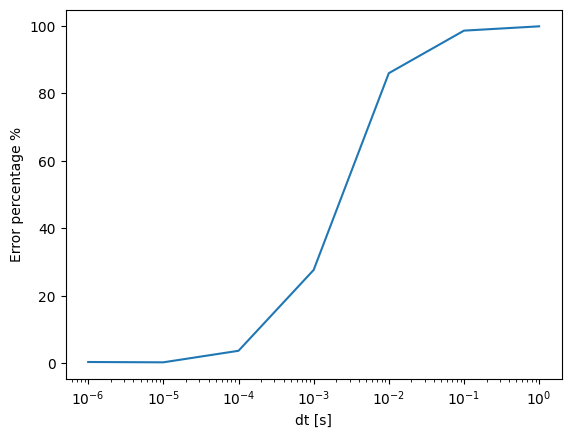

In [17]:
#PLotting
plt.xlabel('dt [s]')
plt.ylabel('Error percentage %')

plt.xscale('log')

plt.plot(nsdt,esdt)
plt.savefig('error_dt.pdf')



The error percentage is very low until we surpass $dt=1.0\cdot10^{-4}$, after that the simulation becomes unreliable.

## Particle size

The size of the particles plays has a great effect in the simulation as in an Ideal Gas the particles interact minimaly with eachother.

In [18]:
#INITIAL CONDITIONS
n = 200 #number of particles
l = 1.0 #side length of the container [m]
m = 0.001 #mass of the particles [kg]
dt = 1e-6 #time step of the simulation [s]
v_med = 500 #median velocity of the particles <v> at t=0 [m/s] 
n_iterations=10000 #number of iterations of the simulation, note that the real time elapsed will be n_iterations*dt

In [19]:
#Particle creation
p1,v1 = get_Particles(n,0.001,l,v_med)
p2,v2 = get_Particles(n,0.005,l,v_med)
p3,v3 = get_Particles(n,0.01,l,v_med)
p4,v4 = get_Particles(n,0.015,l,v_med)
p5,v5 = get_Particles(n,0.02,l,v_med)
p6,v6 = get_Particles(n,0.025,l,v_med)
p7,v7 = get_Particles(n,0.03,l,v_med)

In [20]:
#simulation 
pR1,vR1,p_Rt1 = Sim(p1,v1,n_iterations,0.001,l,dt)
pR2,vR2,p_Rt2 = Sim(p2,v2,n_iterations,0.005,l,dt)
pR3,vR3,p_Rt3 = Sim(p3,v3,n_iterations,0.01,l,dt)
pR4,vR4,p_Rt4 = Sim(p4,v4,n_iterations,0.015,l,dt)
pR5,vR5,p_Rt5 = Sim(p5,v5,n_iterations,0.02,l,dt)
pR6,vR6,p_Rt6 = Sim(p6,v6,n_iterations,0.025,l,dt)
pR7,vR7,p_Rt7 = Sim(p7,v7,n_iterations,0.03,l,dt)

KeyboardInterrupt: 

In [ ]:
#Error Calculation
e1 = get_Error(n,m,v_med,p_Rt1,l,n_iterations, dt)
e2 = get_Error(n,m,v_med,p_Rt2,l,n_iterations, dt)
e3 = get_Error(n,m,v_med,p_Rt3,l,n_iterations, dt)
e4 = get_Error(n,m,v_med,p_Rt4,l,n_iterations, dt)
e5 = get_Error(n,m,v_med,p_Rt5,l,n_iterations, dt)
e6 = get_Error(n,m,v_med,p_Rt6,l,n_iterations, dt)
e7 = get_Error(n,m,v_med,p_Rt7,l,n_iterations, dt)

nsR = np.array([0.001,0.005,0.01,0.015,0.02,0.025,0.03])
esR = np.array([e1,e2,e3,e4,e5,e6,e7])

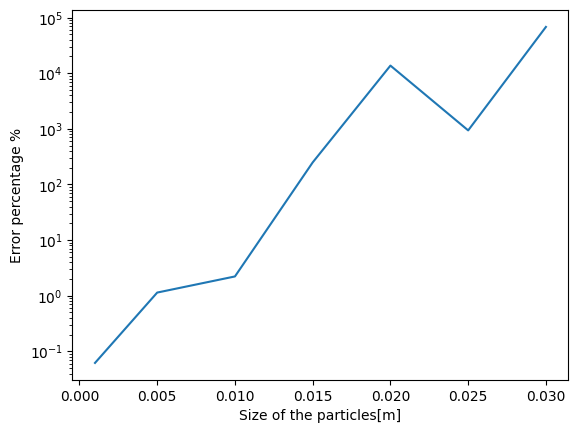

In [ ]:
#PLotting
plt.xlabel('Size of the particles[m]')
plt.ylabel('Error percentage %')

plt.yscale('log')

plt.plot(nsR,esR)
plt.savefig('error_r.pdf')
plt.show()


The difference in results between each particle size is enormous, with the radii bigger than $0.01$ producing more than $100\%$ error

## Mean initial velocity

Another initial condition that is extremly important to stablish is the minimal and maximal velocity the simulation can handle, as its known that the Ideal gas law is not applicable to exceedingly hot or cold gases.

In [ ]:
#INITIAL CONDITIONS
n = 200 #number of particles
R = 0.001 #radius of the particles [m]
l = 1.0 #side length of the container [m]
m = 0.001 #mass of the particles [kg]
dt = 1e-6 #time step of the simulation [s]
n_iterations=10000 #number of iterations of the simulation, note that the real time elapsed will be n_iterations*dt

In [ ]:
#Particle creation
p0,v0 = get_Particles(n,R,l,10)
p1,v1 = get_Particles(n,R,l,50)
p2,v2 = get_Particles(n,R,l,100)
p3,v3 = get_Particles(n,R,l,200)
p4,v4 = get_Particles(n,R,l,400)
p5,v5 = get_Particles(n,R,l,500)
p6,v6 = get_Particles(n,R,l,600)
p7,v7 = get_Particles(n,R,l,800)

In [ ]:
#simulation
pv0,vv0,p_vt0 = Sim(p0,v0,n_iterations,R,l,dt)
pv1,vv1,p_vt1 = Sim(p1,v1,n_iterations,R,l,dt)
pv2,vv2,p_vt2 = Sim(p2,v2,n_iterations,R,l,dt)
pv3,vv3,p_vt3 = Sim(p3,v3,n_iterations,R,l,dt)
pv4,vv4,p_vt4 = Sim(p4,v4,n_iterations,R,l,dt)
pv5,vv5,p_vt5 = Sim(p5,v5,n_iterations,R,l,dt)
pv6,vv6,p_vt6 = Sim(p6,v6,n_iterations,R,l,dt)
pv7,vv7,p_vt7 = Sim(p7,v7,n_iterations,R,l,dt)

C:\Users\Cliente\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\numpy\core\fromnumeric.py:1859: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return asanyarray(a).ravel(order=order)


In [ ]:
#Error calculations
e0 = get_Error(n,m,10,p_vt0,l,n_iterations, dt)
e1 = get_Error(n,m,50,p_vt1,l,n_iterations, dt)
e2 = get_Error(n,m,100,p_vt2,l,n_iterations, dt)
e3 = get_Error(n,m,200,p_vt3,l,n_iterations, dt)
e4 = get_Error(n,m,400,p_vt4,l,n_iterations, dt)
e5 = get_Error(n,m,500,p_vt5,l,n_iterations, dt)
e6 = get_Error(n,m,600,p_vt6,l,n_iterations, dt)
e7 = get_Error(n,m,800,p_vt7,l,n_iterations, dt)

nsv = np.array([10,50,100,200,400,500,600,800])
esv = np.array([e0,e1,e2,e3,e4,e5,e6,e7])

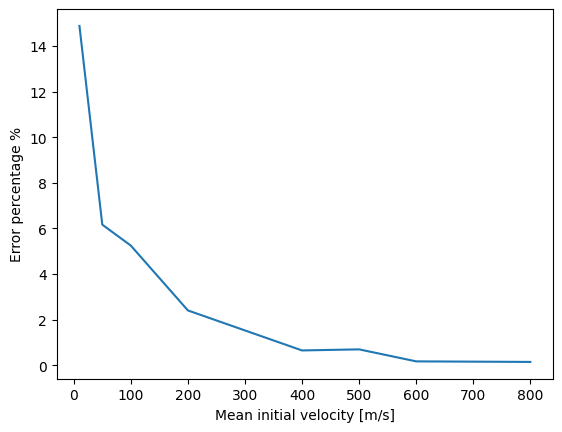

In [ ]:
#PLotting
plt.xlabel('Mean initial velocity [m/s]')
plt.ylabel('Error percentage %')


plt.plot(nsv,esv)
plt.savefig('error_mv.pdf')
plt.show()

We can see that the simulation breaks under low speeds but stays under $5\%$ in higher velocities.

## Final Simulation

After this analysis we can conclude that a simulation with the following initial conditions will produce appropriate result:
- __Time step__ = $1\cdot 10^{-5}$
- __Number of particles__ = 300
- __Particle size__ = 0.001 m
- __Initial velocity__ = 600 m/s

In [ ]:
#INITIAL CONDITIONS
n = 300 #number of particles
R = 0.001 #radius of the particles [m]
l = 1.0 #side length of the container [m]
m = 0.001 #mass of the particles [kg]
dt = 1e-5 #time step of the simulation [s]
v_med = 600 #initial velocity
n_iterations=10000 #number of iterations of the simulation, note that the real time elapsed will be n_iterations*dt

In [ ]:
#Particle creation
p,v = get_Particles(n,R,l,v_med)

#Simulation
ps,vs,p_t = Sim(p,v,n_iterations,R,l,dt)

#Error calculation
e = get_Error(n,m,v_med,p_t,l,n_iterations, dt)


C:\Users\Cliente\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\numpy\core\fromnumeric.py:1859: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return asanyarray(a).ravel(order=order)


In [ ]:
print('The final error is: ',e,'%')


The final error is:  0.242 %


The final error of the simulation is below $5\%$ showing that using the Kinetic Theory of gases the Ideal gas law is true, we can also do a visualisation of the behaviour of the particles using a side view animation.

In [ ]:
#width and height of the image
w = 500

canvas = Canvas(width=w, height=w)
display(canvas)

#"frame rate of the animation"
f_rate = 1

for j in range(0,int(np.ceil(n_iterations/(2*f_rate)))):
    with hold_canvas(canvas):
        
        canvas.clear() # clear the canvas before drawing
        
        #white box representing the volume
        canvas.stroke_style = "black"
        canvas.stroke_line(0, 0, 0, l*w)
        
        canvas.stroke_style = "black"
        canvas.stroke_line(0, 0, l*w, 0)
        
        canvas.stroke_style = "black"
        canvas.stroke_line(l*w, l*w, l*w, 0)
        
        canvas.stroke_style = "black"
        canvas.stroke_line(l*w, l*w, 0, l*w)

        
        for i in range(n): # loop over all particles
                canvas.fill_style = 'red' # fill color for the particles
                canvas.fill_arc(ps[2*f_rate*j][i][0]*w, ps[2*f_rate*j][i][2]*w, R*w*2, 0, 2*np.pi)


Canvas(width=500)

# Maxwell-Boltzmann Distribution

As a consequence of how the previous simulation is structured the particle velocities roughly obey the Maxwell-Boltzmann distribution of velocities $^{[1]}$, that is:

\begin{equation*}
    f(v) = \left( \frac{m}{2\pi KT} \right) ^\frac{3}{2} 4\pi v^2 exp \left(\frac{-mv^2}{2KT} \right)
\end{equation*}

Using the relation for Temperature previously derived we can also write the distribution as:

\begin{equation*}
    f(v) = \left(\frac{3}{2\pi \left<v \right>^2} \right)^\frac{3}{2} 4\pi v^2 exp \left(\frac{-3v^2}{2\left<v \right>^2} \right)
\end{equation*}

For the sake of the demonstration a bigger particle radius is prefered as it will reach equilibrium faster.

In [ ]:
#INITIAL CONDITIONS
n = 300 #number of particles
R = 0.01 #radius of the particles [m]
l = 1.0 #side length of the container [m]
m = 0.001 #mass of the particles [kg]
dt = 1e-5 #time step of the simulation [s]
v_med = 600 #initial velocity
n_iterations=10000 #number of iterations of the simulation, note that the real time elapsed will be n_iterations*dt

In [ ]:
#Particle creation
pw,vw = get_Particles(n,R,l,v_med)

#Simulation
pws,vws,p_tw = Sim(pw,vw,n_iterations,R,l,dt)

In [ ]:
#getting the final velocity distribution
v_final = np.asarray(vws[n_iterations-1], dtype=float)

#getting the total velocity of every particle at the final time step
h = np.sqrt(np.sum(v_final**2,axis=1))

In [ ]:
#sample points for the distribution
ws = np.linspace(0,2000,1000)

#caulculation of the distribution for every sample point 
fv = ((3/(2*np.pi*(v_med**2)))**(3/2))*4*np.pi*(ws**2)*np.exp(-3*(ws**2)/(2*(v_med**2)))

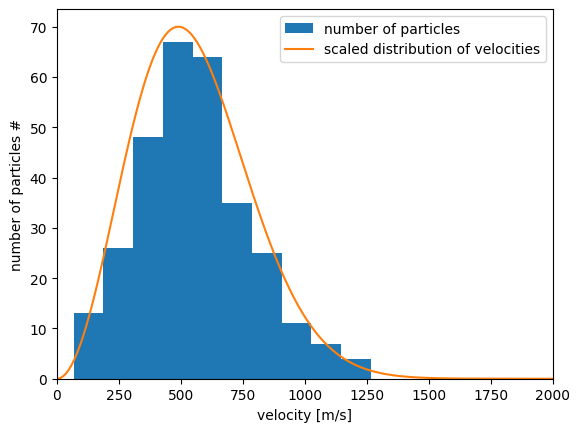

In [ ]:
#scalar to facilitate the comparison between the distribution and final result
scalar = 70/(max(fv))

#plot
plt.figure()
plt.xlim(0,2000)
plt.xlabel('velocity [m/s]')
plt.ylabel('number of particles #')
plt.hist(h, label = 'number of particles ')
plt.plot(ws,fv*scalar, label = 'scaled distribution of velocities')
plt.legend(loc = 'upper right')
plt.savefig('blotzmann.pdf')

We can see that the final distribution feats into the calculated distribution. Analising the animation the equilibration becomes clear.

In [ ]:
#width and height of the image
w = 500

canvas = Canvas(width=w, height=w)
display(canvas)

#"frame rate of the animation"
f_rate = 5

for j in range(0,int(np.ceil(n_iterations/(2*f_rate)))):
    with hold_canvas(canvas):
        
        canvas.clear() # clear the canvas before drawing
        
        #white box representing the volume
        canvas.stroke_style = "black"
        canvas.stroke_line(0, 0, 0, l*w)
        
        canvas.stroke_style = "black"
        canvas.stroke_line(0, 0, l*w, 0)
        
        canvas.stroke_style = "black"
        canvas.stroke_line(l*w, l*w, l*w, 0)
        
        canvas.stroke_style = "black"
        canvas.stroke_line(l*w, l*w, 0, l*w)

        
        for i in range(n): # loop over all particles
                canvas.fill_style = 'black' # fill color for the particles
                canvas.fill_arc(pws[2*f_rate*j][i][0]*w, pws[2*f_rate*j][i][2]*w, R*w, 0, 2*np.pi)

Canvas(width=500)

## Summary

With this we can see that using numerical integration methods, appropiate initial conditions and the aproximations made by the Kinetic theory of gases it is possible to prove with a minimal discrepancy not only the Ideal gas law as well as the Maxwell-Boltzmann distribution of velocities.

## References

[1] Thermal Physics by STEPHEN J. BLUNDELL AND KATHERINE M. BLUNDELL